# Проверка статистических гипотез о средних

### Выбор теста

| Задача | Тест |
|---|---|
| ✅ Среднее против конкретного числа | Одновыборочный t-тест |
| ✅ Средние двух независимых групп | t-тест для независимых выборок |
| ✅ Средние до/после | Парный t-тест |
| Одна доля против константы | Z-тест для доли |
| Две доли | Z-тест для двух долей |
| Связь категориальных переменных | Хи-квадрат |
| 🟡 Две независимые группы без нормальности | Манн–Уитни |
| 🟡 Две связанные группы без нормальности | Уилкоксон |

## Одновыборочный t-тест

Используется, когда нужно сравнить среднее значение выборки с конкретным числом.

**Пример задачи**

Есть данные о времени выполнения задания студентами. Считается, что среднее время выполнения равно 30 минут. Проверим, отличаются ли реальные данные от этого значения.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats

Исходные данные:

In [2]:
times = np.array([15, 10, 7, 9, 10, 35, 20, 22, 17, 7])
mu_0 = 30
alpha = 0.05

Стат. тест: 

In [3]:
t_stat, p_value = stats.ttest_1samp(
    times,
    popmean=mu_0
)

print(f"t-статистика: {t_stat:.3f}")
print(f"p-value: {p_value:.5f}")

t-статистика: -5.339
p-value: 0.00047


**Интерпретация**

Если p-value меньше или равно 0.05, мы считаем различие статистически значимым.

In [4]:
if p_value <= alpha:
    print("Нулевая гипотеза отвергается")
else:
    print("Нет оснований отвергнуть нулевую гипотезу")

Нулевая гипотеза отвергается


## Визуализация

In [5]:
import matplotlib.pyplot as plt

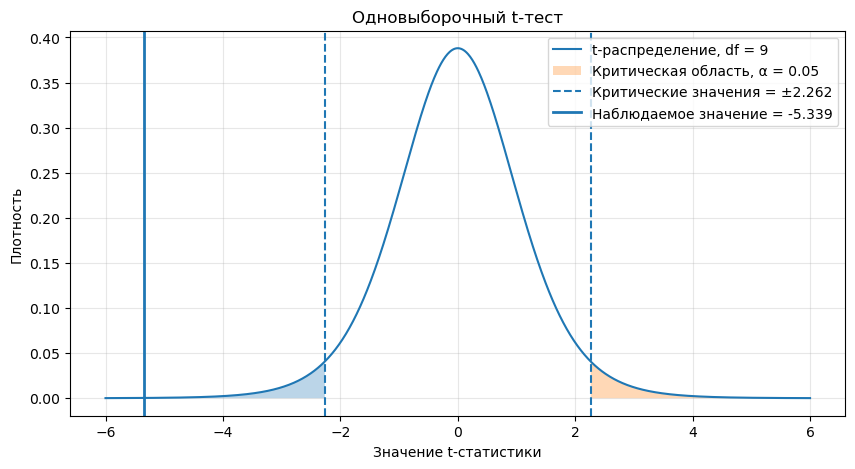

In [6]:
df = len(times) - 1 # размер выборки
critical_value = stats.t.ppf(1 - alpha / 2, df) # критическое значение

x = np.linspace(-6, 6, 1000)
y = stats.t.pdf(x, df)

plt.figure(figsize=(10, 5))

plt.plot(x, y, label=f"t-распределение, df = {df}")

plt.fill_between(x[x <= -critical_value], stats.t.pdf(x[x <= -critical_value], df), alpha=0.3)
plt.fill_between(x[x >= critical_value], stats.t.pdf(x[x >= critical_value], df), alpha=0.3, label=f"Критическая область, α = {alpha}")

plt.axvline(-critical_value, linestyle="--", label=f"Критические значения = ±{critical_value:.3f}")
plt.axvline(critical_value, linestyle="--")
plt.axvline(t_stat, linewidth=2, label=f"Наблюдаемое значение = {t_stat:.3f}")

plt.title("Одновыборочный t-тест")
plt.xlabel("Значение t-статистики")
plt.ylabel("Плотность")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## t-тест для независимых выборок

Используется, когда нужно сравнить средние значения в двух независимых группах.

**Пример задачи**

Сравним результаты двух независимых групп студентов.

In [7]:
group_a = np.array([78, 82, 85, 90, 88, 76])
group_b = np.array([70, 75, 72, 68, 74, 71])

alpha = 0.05

Стат. тест: 

In [8]:
t_stat, p_value = stats.ttest_ind(
    group_a,
    group_b
)

print(f"t-статистика: {t_stat:.3f}")
print(f"p-value: {p_value:.5f}")

t-статистика: 4.616
p-value: 0.00096


**Интерпретация**

In [9]:
if p_value <= alpha:
    print("Средние значения статистически значимо различаются")
else:
    print("Нет оснований считать средние значения различными")

Средние значения статистически значимо различаются


## Визуализация

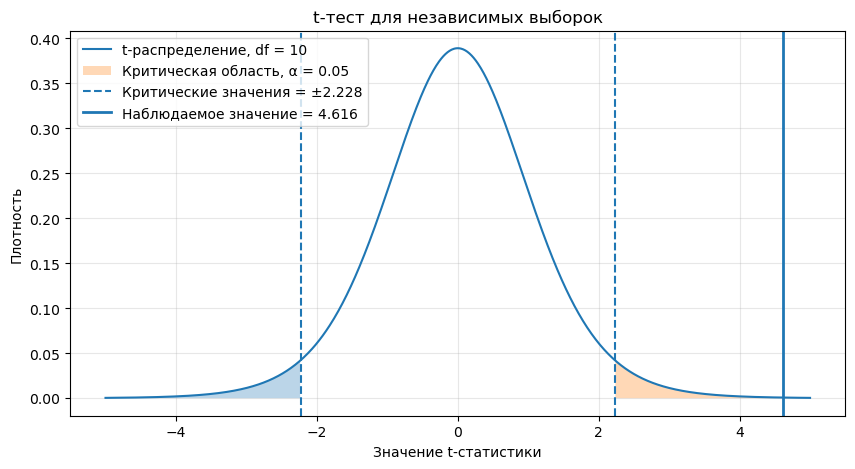

In [10]:
df = len(group_a) + len(group_b) - 2
critical_value = stats.t.ppf(1 - alpha / 2, df)

x = np.linspace(-5, 5, 1000)
y = stats.t.pdf(x, df)

plt.figure(figsize=(10, 5))

plt.plot(x, y, label=f"t-распределение, df = {df}")

plt.fill_between(x[x <= -critical_value], stats.t.pdf(x[x <= -critical_value], df), alpha=0.3)
plt.fill_between(x[x >= critical_value], stats.t.pdf(x[x >= critical_value], df), alpha=0.3, label=f"Критическая область, α = {alpha}")

plt.axvline(-critical_value, linestyle="--", label=f"Критические значения = ±{critical_value:.3f}")
plt.axvline(critical_value, linestyle="--")
plt.axvline(t_stat, linewidth=2, label=f"Наблюдаемое значение = {t_stat:.3f}")

plt.title("t-тест для независимых выборок")
plt.xlabel("Значение t-статистики")
plt.ylabel("Плотность")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Парный t-тест

Используется, когда сравниваются два измерения у одних и тех же объектов.

**Пример задачи**

Сравним результаты студентов до и после обучения.

In [11]:
before = np.array([60, 65, 70, 72, 68, 75])
after = np.array([72, 70, 78, 80, 76, 82])

alpha = 0.05

Стат. тест: 

In [12]:
t_stat, p_value = stats.ttest_rel(
    before,
    after
)

print(f"t-статистика: {t_stat:.3f}")
print(f"p-value: {p_value:.5f}")

t-статистика: -8.593
p-value: 0.00035


**Интерпретация**

In [13]:
if p_value <= alpha:
    print("Результаты до и после статистически значимо различаются")
else:
    print("Нет оснований считать, что результаты изменились")

Результаты до и после статистически значимо различаются


## Визуализация

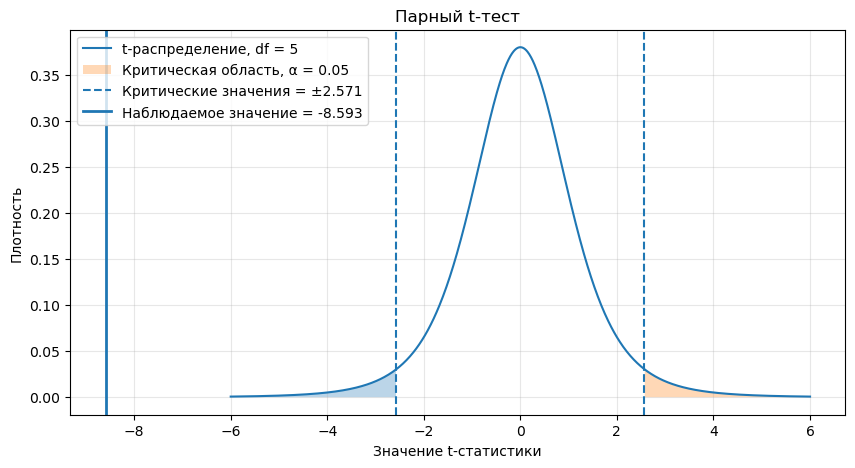

In [14]:
df = len(before) - 1
critical_value = stats.t.ppf(1 - alpha / 2, df)

x = np.linspace(-6, 6, 1000)
y = stats.t.pdf(x, df)

plt.figure(figsize=(10, 5))

plt.plot(x, y, label=f"t-распределение, df = {df}")

plt.fill_between(x[x <= -critical_value], stats.t.pdf(x[x <= -critical_value], df), alpha=0.3)
plt.fill_between(x[x >= critical_value], stats.t.pdf(x[x >= critical_value], df), alpha=0.3, label=f"Критическая область, α = {alpha}")

plt.axvline(-critical_value, linestyle="--", label=f"Критические значения = ±{critical_value:.3f}")
plt.axvline(critical_value, linestyle="--")
plt.axvline(t_stat, linewidth=2, label=f"Наблюдаемое значение = {t_stat:.3f}")

plt.title("Парный t-тест")
plt.xlabel("Значение t-статистики")
plt.ylabel("Плотность")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Непараметрические тесты

Непараметрические тесты используются, когда данные не подходят для параметрических тестов:

- распределение сильно отличается от нормального
- есть выбросы
- выборка маленькая
- данные представлены в порядковой шкале


### Критерий Манна–Уитни

Используется для сравнения двух независимых групп.

Исходные данные:

In [15]:
group_a = np.array([10, 12, 13, 15, 18])
group_b = np.array([20, 22, 19, 25, 24])

Стат. тест: 

In [16]:
u_stat, p_value = stats.mannwhitneyu(
    group_a,
    group_b,
    alternative="two-sided"
)

print(f"U-статистика: {u_stat:.3f}")
print(f"p-value: {p_value:.5f}")

U-статистика: 0.000
p-value: 0.00794


## Визуализация

Для непараметрических график нужен не для проверки гипотезы, а для понимания характера различий.

Для теста Манна-Уитни мы смотрим на положение "коробок" (прямоугольники на графике).

- Если коробки находятся на разном уровне, то значения второй группы в целом выше. Именно это и должен подтвердить тест.
- Если коробки (почти) не пересекаются, это говорит о сильно выраженных различиях
- Визуально смотрим на выбросы (если они есть, то обозначаются точками над или под "усами")

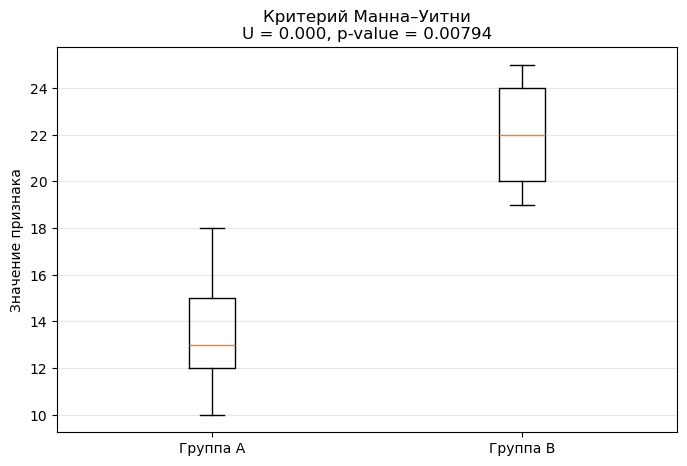

In [17]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [group_a, group_b],
    labels=["Группа A", "Группа B"]
)

plt.title(f"Критерий Манна–Уитни\nU = {u_stat:.3f}, p-value = {p_value:.5f}")
plt.ylabel("Значение признака")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Критерий Уилкоксона

Для сравнения двух связанных измерений

Исходные данные:

In [18]:
before = np.array([10, 12, 13, 15, 18])
after = np.array([12, 14, 13, 18, 20])

Стат. тест: 

In [19]:
w_stat, p_value = stats.wilcoxon(
    before,
    after
)

print(f"W-статистика: {w_stat:.3f}")
print(f"p-value: {p_value:.5f}")

/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


W-статистика: 0.000
p-value: 0.05878


## Визуализация

**Как смотреть график?**

Мы смотрим на направление линий: если все идут вниз или все идут вверх – изменения согласованы. Если половина идёт вверх, а другая половина вниз, то систематического изменения нет. Также нужно обращать внимание на размер изменения – насколько сильно отличаются значения "до" и "после".

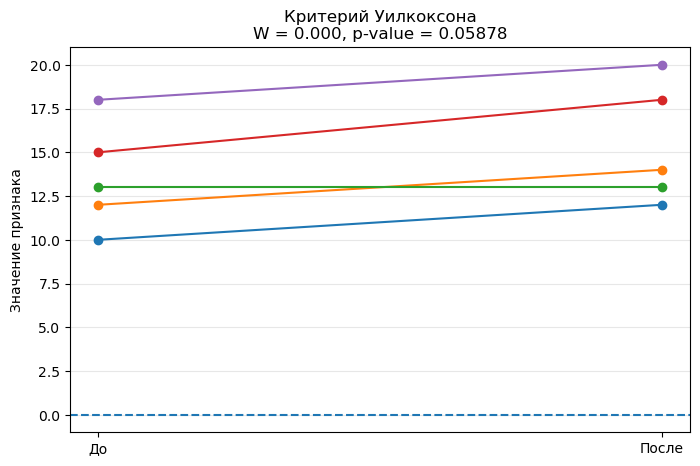

In [20]:
differences = after - before

plt.figure(figsize=(8, 5))

plt.axhline(0, linestyle="--")

for i in range(len(before)):
    plt.plot([0, 1], [before[i], after[i]], marker="o")

plt.xticks([0, 1], ["До", "После"])
plt.title(f"Критерий Уилкоксона\nW = {w_stat:.3f}, p-value = {p_value:.5f}")
plt.ylabel("Значение признака")
plt.grid(axis="y", alpha=0.3)

plt.show()